
# PCEV Exposome ODQ Overview (single figure)

ODQ (no scanner) exposome summary: column 1 shows h² split violins (best vs all_features) for all exposomes (vertical, top row only); columns 2–6 show EI_rate VIP bars (row 1) and corresponding brain maps (row 2) for the top five exposomes (ranked by mean h²). "Democracy-Summary" is excluded.


In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from collections import OrderedDict
from typing import Dict, List
import vtk
import brainspace.plotting.base as bs_base
import sys
from neuromaps.datasets import fetch_fslr
from surfplot import Plot
import nibabel as nb

plt.rcParams['text.usetex'] = False
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'data' / 'derived').exists():
    for parent in REPO_ROOT.parents:
        if (parent / 'data' / 'derived').exists() and (parent / 'analysis').exists():
            REPO_ROOT = parent
            break
DATA_PATH = REPO_ROOT / 'data/derived/model_output_plus_exposome_data_v3.csv'
RESULTS_BASE = Path(os.environ.get('PCEV_RESULTS_DIR', '/data/workspaces/neuromodelling/rherzog/Brainlat/BOLD/pcev_results')) / 'exposome_odq_only_no_scanner'
FIG_DIR = REPO_ROOT / 'analysis/figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR = REPO_ROOT / 'analysis/tables'
TABLE_DIR.mkdir(parents=True, exist_ok=True)


ID_COL = 'N_MEGA'
VIOLIN_COLORS = ['#3498db', '#c7c7c7']  # best, all_features
VIP_CMAP = 'RdBu_r'
VIP_NORM = Normalize(vmin=-0.35, vmax=0.35)

# Exposome definitions (unchanged)
EXPOSOME_GROUPS = OrderedDict({
    'Air Pollution': OrderedDict({
        'PM2.5': 'PM2.5_interpolated',
        'Nitrogen oxides (NOx)': 'Nitrogen oxide (NOx)_interpolated',
        'Sulfur dioxide (SO₂)': 'Sulphur dioxide (SO₂) emissions_interpolated',
        'Carbon monoxide (CO)': 'Carbon monoxide (CO) emissions_interpolated',
        'Black carbon (BC)': 'Black carbon (BC) emissions_interpolated',
        'Ammoniac Nitrogen (NH3)': 'Ammonia (NH₃) emissions_interpolated',
        'Non-methane volatile organic compounds (NMVOC)': 'Non-methane volatile organic compounds (NMVOC) emissions_interpolated',
    }),
    'Green space access': OrderedDict({
        'Urban green area (%) 1990': 'Average share of green area in city/urban area 1990 (%)_interpolated',
        'Urban green area (%) 2000': 'Average share of green area in city/ urban area 2000 (%)_interpolated',
        'Urban green area (%) 2010': 'Average share of green area in city/ urban area 2010 (%)_interpolated',
        'Urban green area (%) 2020': 'Average share of green area in city/ urban area 2020 (%)_interpolated',
        'Green area per capita (m²/person) 1990': 'Green area per capita 1990 (m2/person)_interpolated',
        'Green area per capita (m²/person) 2000': 'Green area per capita 2000 (m2/person)_interpolated',
        'Green area per capita (m²/person) 2010': 'Green area per capita 2010 (m2/person)_interpolated',
        'Green area per capita (m²/person) 2020': 'Green area per capita 2020 (m2/person)_interpolated',
    }),
    'Temperature': OrderedDict({
        'Mean temperature': 'mean_temp_areaw_o_interpolated',
        'Mean temperature pop-weighted': 'mean_temp_o_interpolated',
        'Mean temperature anomalies': 'mean_anomalies_areaw_o_interpolated',
        'Mean temperature anomalies pop-weighted': 'mean_anomalies_o_interpolated',
        'Deviation of temperature anomalies': 'sd_lr_o_interpolated',
        'Max temperature': 'maxgtemp_o_interpolated',
    }),
    'Precipitation-droughts': OrderedDict({
        'Mean precipitation': 'mean_prec2_areaw_o_interpolated',
        'Mean precipitation pop-weighted': 'mean_prec2_o_interpolated',
        'Palmer drought severity index': 'scpdsi_aw_o_interpolated',
        'Palmer drought severity index pop-weighted': 'scpdsi_o_interpolated',
    }),
    'Soil and water quality': OrderedDict({
        'Poisoning mortality rate': 'Poisoning_mortality_rate_interpolated',
        'Basic drinking water access': 'Pop_basic_drinking-water(%)_interpolated',
        'Safely-managed drinking water access': 'Pop_safely_drinking-water(%)_interpolated',
        'Agriculture employment rate': 'agri_emp_o_interpolated',
    }),
    'Climate disasters': OrderedDict({
        'Number of disaster events': 'climatedisaster_count_o_interpolated',
        'Population affected': 'climatedisaster_naffected_o_interpolated',
    }),
    'Disease-related mortality': OrderedDict({
        'Non-communicable death rate (%)': 'deaths_notrans_interpolated',
        'Communicable death rate (%)': 'deaths_trans_interpolated',
    }),
    'Socioeconomic': OrderedDict({
        'Gini index': 'GINI_interpolated',
        'Human capital index': 'HCI_interpolated',
        'Human development index (HDI)': 'HDI_interpolated',
        'Inequality-Adjusted HDI': 'IHDI_interpolated',
        'Multidimensional poverty measures': 'MPM_interpolated',
        'Energy demand': 'Electricity_demand_interpolated',
        'Gender inequality index': 'GII_interpolated',
        'Unemployment rate': 'unemp_interpolated',
        'GDP per capita': 'GDP_interpolated',
    }),
    'Democracy': OrderedDict({
        'Credible elections': 'cred_elect_est_interpolated',
        'Inclusive suffrage': 'inclu_suff_est_interpolated',
        'Free parties': 'free_parties_est_interpolated',
        'Elected government': 'elected_gov_est_interpolated',
        'Effective parliament': 'effect_parl_est_interpolated',
        'Local democracy': 'local_dem_est_interpolated',
        'Access to justice': 'access_just_est_interpolated',
        'Civil liberties': 'civil_lib_est_interpolated',
        'Freedom of expression (Civil liberties)': 'free_express_est_interpolated',
        'Freedom of the press (Civil liberties)': 'free_press_est_interpolated',
        'Freedom of association and assembly (Civil liberties)': 'free_assoc_assem_est_interpolated',
        'Freedom of religion (Civil liberties)': 'free_relig_est_interpolated',
        'Freedom of movement (Civil liberties)': 'free_move_est_interpolated',
        'Political equality': 'pol_equal_est_interpolated',
        'Social group equality (Political equality)': 'soc_grp_equal_est_interpolated',
        'Economic equality (Political equality)': 'econ_equal_est_interpolated',
        'Gender equality (Political equality)': 'gender_equal_est_interpolated',
        'Judicial independence': 'jud_ind_est_interpolated',
        'Absence of Corruption': 'abs_corrupt_est_interpolated',
        'Predictability enforcement': 'predict_enf_est_interpolated',
        'Personal integrity and security': 'pers_integ_sec_est_interpolated',
        'Civil society': 'civil_soc_est_interpolated',
        'Civic engagement': 'civic_engage_est_interpolated',
        'Electoral participation': 'elect_part_est_interpolated',
        'Direct democracy': 'direct_dem_est_interpolated',
    }),
    'Democracy-Summary': OrderedDict({
        'Political representation': 'representation_est_interpolated',
        'Rights': 'rights_est_interpolated',
        'Basic welfare': 'basic_welf_est_interpolated',
        'Rule of law': 'rule_law_est_interpolated',
        'Participation': 'participation_est_interpolated',
    }),
    'Migration': OrderedDict({
        'Inbound migration rate': 'migration_interpolated',
    }),
})

vip_feature_groups = ['rate_E', 'rate_I', 'EI_rate', 'ent_E', 'ent_I', 'EI_ent']

# Load data and ROI
main_df = pd.read_csv(DATA_PATH, low_memory=False)
main_df = main_df[~main_df['Country'].str.strip().str.lower().eq('new zeland')]
main_df[ID_COL] = main_df[ID_COL].astype(str).str.strip()
roi_df = pd.read_csv(REPO_ROOT / 'data/derived/ROI_MNI_V4.csv')
roi_regions = roi_df['label'].tolist()

feature_cols_by_group = {g: [c for c in main_df.columns if c.startswith(f"{g}_")] for g in vip_feature_groups}
all_feature_cols = sorted({c for cols in feature_cols_by_group.values() for c in cols})

def safe_name(name: str) -> str:
    return name.replace(' ', '_')

def feature_to_region(feature: str) -> str:
    parts = feature.split('_')
    try:
        idx = int(parts[-1])
    except ValueError:
        return 'ROI?'
    return roi_regions[idx] if idx < len(roi_regions) else f'ROI {idx}'

def compute_vip(score_df: pd.DataFrame, feature_cols_by_group: Dict[str, List[str]], main_df: pd.DataFrame, label: str) -> pd.DataFrame:
    score_df = score_df[['subject_id', 'score_with']].dropna().copy()
    merged = score_df.merge(
        main_df[[ID_COL] + all_feature_cols],
        left_on='subject_id', right_on=ID_COL, how='inner'
    )
    if merged.empty:
        raise ValueError(f'No overlap between {label} scores and main data')
    results = []
    for group, cols in feature_cols_by_group.items():
        corrs = merged[cols].apply(lambda col: col.corr(merged['score_with']))
        results.append(pd.DataFrame({
            'feature_group': group,
            'feature': cols,
            'vip': corrs.values,
            'exposome': label,
        }))
    return pd.concat(results, ignore_index=True)

def top_vip_ei(vip_df: pd.DataFrame, top_n: int = 8) -> pd.DataFrame:
    vip = vip_df[vip_df['feature_group'] == 'EI_rate'].copy()
    vip['abs_vip'] = vip['vip'].abs()
    vip = vip.sort_values('abs_vip', ascending=False).head(top_n)
    vip['region'] = vip['feature'].apply(feature_to_region)
    vip['label_short'] = vip['region']
    return vip

def remove_excluded_regions(vec):
    mask = np.ones(90, dtype=bool)
    mask[70:78] = False
    return np.array(vec)[mask]

# Brain plotting helpers
def _patch_vtk_mro_for_vtkname():
    probe = vtk.vtkPolyData()
    for cls in probe.__class__.mro():
        if cls is object:
            continue
        if not hasattr(cls, "__vtkname__"):
            nm = cls.__name__
            if not nm.startswith('vtk'):
                nm = f'vtk{nm}'
            cls.__vtkname__ = nm
_patch_vtk_mro_for_vtkname()

def patched_to_numpy(self, transparent_bg=True, scale=None):
    wf = self._win2img(transparent_bg, scale)
    img = bs_base.get_output(wf)
    dims = None
    if hasattr(img, 'GetDimensions'):
        try:
            dims = img.GetDimensions()
        except Exception:
            dims = None
    if dims is None and hasattr(img, 'dimensions'):
        d = img.dimensions
        if callable(d):
            dims = d()
        else:
            dims = d
    dims = tuple(dims)
    shape = dims[::-1][1:] + (-1,)
    scalars = img.PointData['ImageScalars']
    if hasattr(scalars, 'to_array'):
        scalars = scalars.to_array()
    scalars = np.asarray(scalars)
    return scalars.reshape(shape)[::-1]
bs_base.Plotter.to_numpy = patched_to_numpy

sys.path.append(str(Path('/home/rherzog/Documents/Brainlat/brainplot')))
def plot_brain_map(mapp, vmin=-0.3, vmax=0.3, cmap='seismic'):
    lh_labels_gii = nb.load('/home/rherzog/Documents/Brainlat/brainplot/AAL.32k.L.label.gii')
    lh_labels = lh_labels_gii.darrays[0].data.astype(int)
    rh_labels_gii = nb.load('/home/rherzog/Documents/Brainlat/brainplot/AAL.32k.R.label.gii')
    rh_labels = rh_labels_gii.darrays[0].data.astype(int)
    Ds_left = mapp[::2]
    Ds_right = mapp[1::2]
    lh_vertex_data = np.zeros_like(lh_labels, dtype=float)
    for i in range(41):
        lh_vertex_data[lh_labels == i+1] = Ds_left[i]
    rh_vertex_data = np.zeros_like(rh_labels, dtype=float)
    for i in range(41):
        rh_vertex_data[rh_labels == i+1] = Ds_right[i]
    surfaces = fetch_fslr()
    lh, rh = surfaces['inflated']
    p = Plot(lh, rh, size=(900, 700), layout='grid', zoom=1.35)
    p.add_layer({'left': lh_vertex_data, 'right': rh_vertex_data}, cmap=cmap, cbar=False, color_range=(vmin, vmax))
    fig = p.build()
    fig.patch.set_alpha(0)
    return fig

# Exposomes to plot (exclude Democracy-Summary)
excluded_exposomes = {"Democracy-Summary"}
exposomes_to_plot = [
    name for name in EXPOSOME_GROUPS.keys()
    if name not in excluded_exposomes and (RESULTS_BASE / safe_name(name)).exists()
]
if not exposomes_to_plot:
    raise ValueError('No exposome directories found after exclusions')

# Load bundles
bundles = {}
for expo_name in exposomes_to_plot:
    expo_dir = RESULTS_BASE / safe_name(expo_name)
    summary_df = pd.read_csv(expo_dir / 'all_combos_summary.csv')
    non_all = summary_df[summary_df['combo_label'] != 'all_features'].copy()
    best_row = non_all.sort_values('h2_with_mean', ascending=False).iloc[0]
    best_combo = best_row['combo_label']
    best_safe = best_combo.replace('+', '_')

    h2_best = pd.read_csv(expo_dir / f'{best_safe}_h2_per_repeat.csv')
    h2_all = pd.read_csv(expo_dir / 'all_features_h2_per_repeat.csv')

    scores_best = pd.read_csv(expo_dir / f'{best_safe}_subject_scores.csv')
    scores_best['subject_id'] = scores_best['subject_id'].astype(str).str.strip()
    scores_best_avg = scores_best.groupby('subject_id', as_index=False)['score_with'].mean()

    vip_df = compute_vip(scores_best_avg, feature_cols_by_group, main_df, label=expo_name)

    bundles[expo_name] = {
        'dir': expo_dir,
        'best_combo': best_combo,
        'h2_best': h2_best,
        'h2_all': h2_all,
        'scores_avg': scores_best_avg,
        'vip_df': vip_df,
        'n_subjects': scores_best_avg.shape[0],
        'h2_mean': h2_best['h2_with'].mean(),
        'h2_best_95ci': (
            h2_best['h2_with'].mean() - 1.96 * h2_best['h2_with'].std() / np.sqrt(len(h2_best)),
            h2_best['h2_with'].mean() + 1.96 * h2_best['h2_with'].std() / np.sqrt(len(h2_best)),
        ),
        'h2_all_95ci': (
            h2_all['h2_with'].mean() - 1.96 * h2_all['h2_with'].std() / np.sqrt(len(h2_all)),
            h2_all['h2_with'].mean() + 1.96 * h2_all['h2_with'].std() / np.sqrt(len(h2_all)),
        ),
    }
    ci_low, ci_high = (
        h2_best['h2_with'].mean() - 1.96 * h2_best['h2_with'].std() / np.sqrt(len(h2_best)),
        h2_best['h2_with'].mean() + 1.96 * h2_best['h2_with'].std() / np.sqrt(len(h2_best)),
    )
    print(
        f"Loaded {expo_name}: best={best_combo}, subjects={scores_best_avg.shape[0]}, "
        f"h2_best_mean={h2_best['h2_with'].mean():.5f} [95% CI: [{ci_low:.6f}, {ci_high:.6f}]]"
    )
    ci_low, ci_high = (
        h2_all['h2_with'].mean() - 1.96 * h2_all['h2_with'].std() / np.sqrt(len(h2_all)),
        h2_all['h2_with'].mean() + 1.96 * h2_all['h2_with'].std() / np.sqrt(len(h2_all)),
    )
    print(
        f"Loaded {expo_name}: best={best_combo}, subjects={scores_best_avg.shape[0]}, "
        f"h2_all_mean={h2_all['h2_with'].mean():.5f} [95% CI: [{ci_low:.6f}, {ci_high:.6f}]]"
    )

# Ranking and violin data
exposome_order = [e for e, _ in sorted([(e, b['h2_mean']) for e, b in bundles.items()], key=lambda t: t[1], reverse=True)]
top_exposomes = exposome_order[:5]

all_violin_df = []
for expo in exposome_order:
    bund = bundles[expo]
    df = pd.DataFrame({
        'h2': pd.concat([bund['h2_best']['h2_with'], bund['h2_all']['h2_with']]),
        'condition': ['best'] * len(bund['h2_best']) + ['all_features'] * len(bund['h2_all']),
    })
    df['exposome'] = expo
    all_violin_df.append(df)
all_violin_df = pd.concat(all_violin_df, ignore_index=True)


Loaded Air Pollution: best=ent_I+rate_I, subjects=6922, h2_best_mean=0.15939 [95% CI: [0.158916, 0.159860]]
Loaded Air Pollution: best=ent_I+rate_I, subjects=6922, h2_all_mean=0.16033 [95% CI: [0.159662, 0.160997]]
Loaded Green space access: best=ent_I, subjects=6922, h2_best_mean=0.00010 [95% CI: [0.000074, 0.000119]]
Loaded Green space access: best=ent_I, subjects=6922, h2_all_mean=0.00004 [95% CI: [0.000028, 0.000050]]
Loaded Temperature: best=EI_ent+ent_E, subjects=6922, h2_best_mean=0.05422 [95% CI: [0.053781, 0.054661]]
Loaded Temperature: best=EI_ent+ent_E, subjects=6922, h2_all_mean=0.04591 [95% CI: [0.045392, 0.046435]]
Loaded Precipitation-droughts: best=rate_I, subjects=6922, h2_best_mean=0.04503 [95% CI: [0.044668, 0.045388]]
Loaded Precipitation-droughts: best=rate_I, subjects=6922, h2_all_mean=0.03295 [95% CI: [0.032504, 0.033405]]
Loaded Soil and water quality: best=EI_rate+rate_I, subjects=5560, h2_best_mean=0.16600 [95% CI: [0.165508, 0.166495]]
Loaded Soil and water q

/home/rherzog/.tmp/ipykernel_25729/2869759019.py:51: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = [cm.get_cmap(VIP_CMAP)(VIP_NORM(v)) for v in vip_ei['vip']]
/home/rherzog/.tmp/ipykernel_25729/2869759019.py:51: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = [cm.get_cmap(VIP_CMAP)(VIP_NORM(v)) for v in vip_ei['vip']]
/home/rherzog/.tmp/ipykernel_25729/2869759019.py:51: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = [cm.get_cmap(VIP_CMAP)

Single overview figure saved to /home/rherzog/Documents/Brainlat/repo_test/analysis/figures


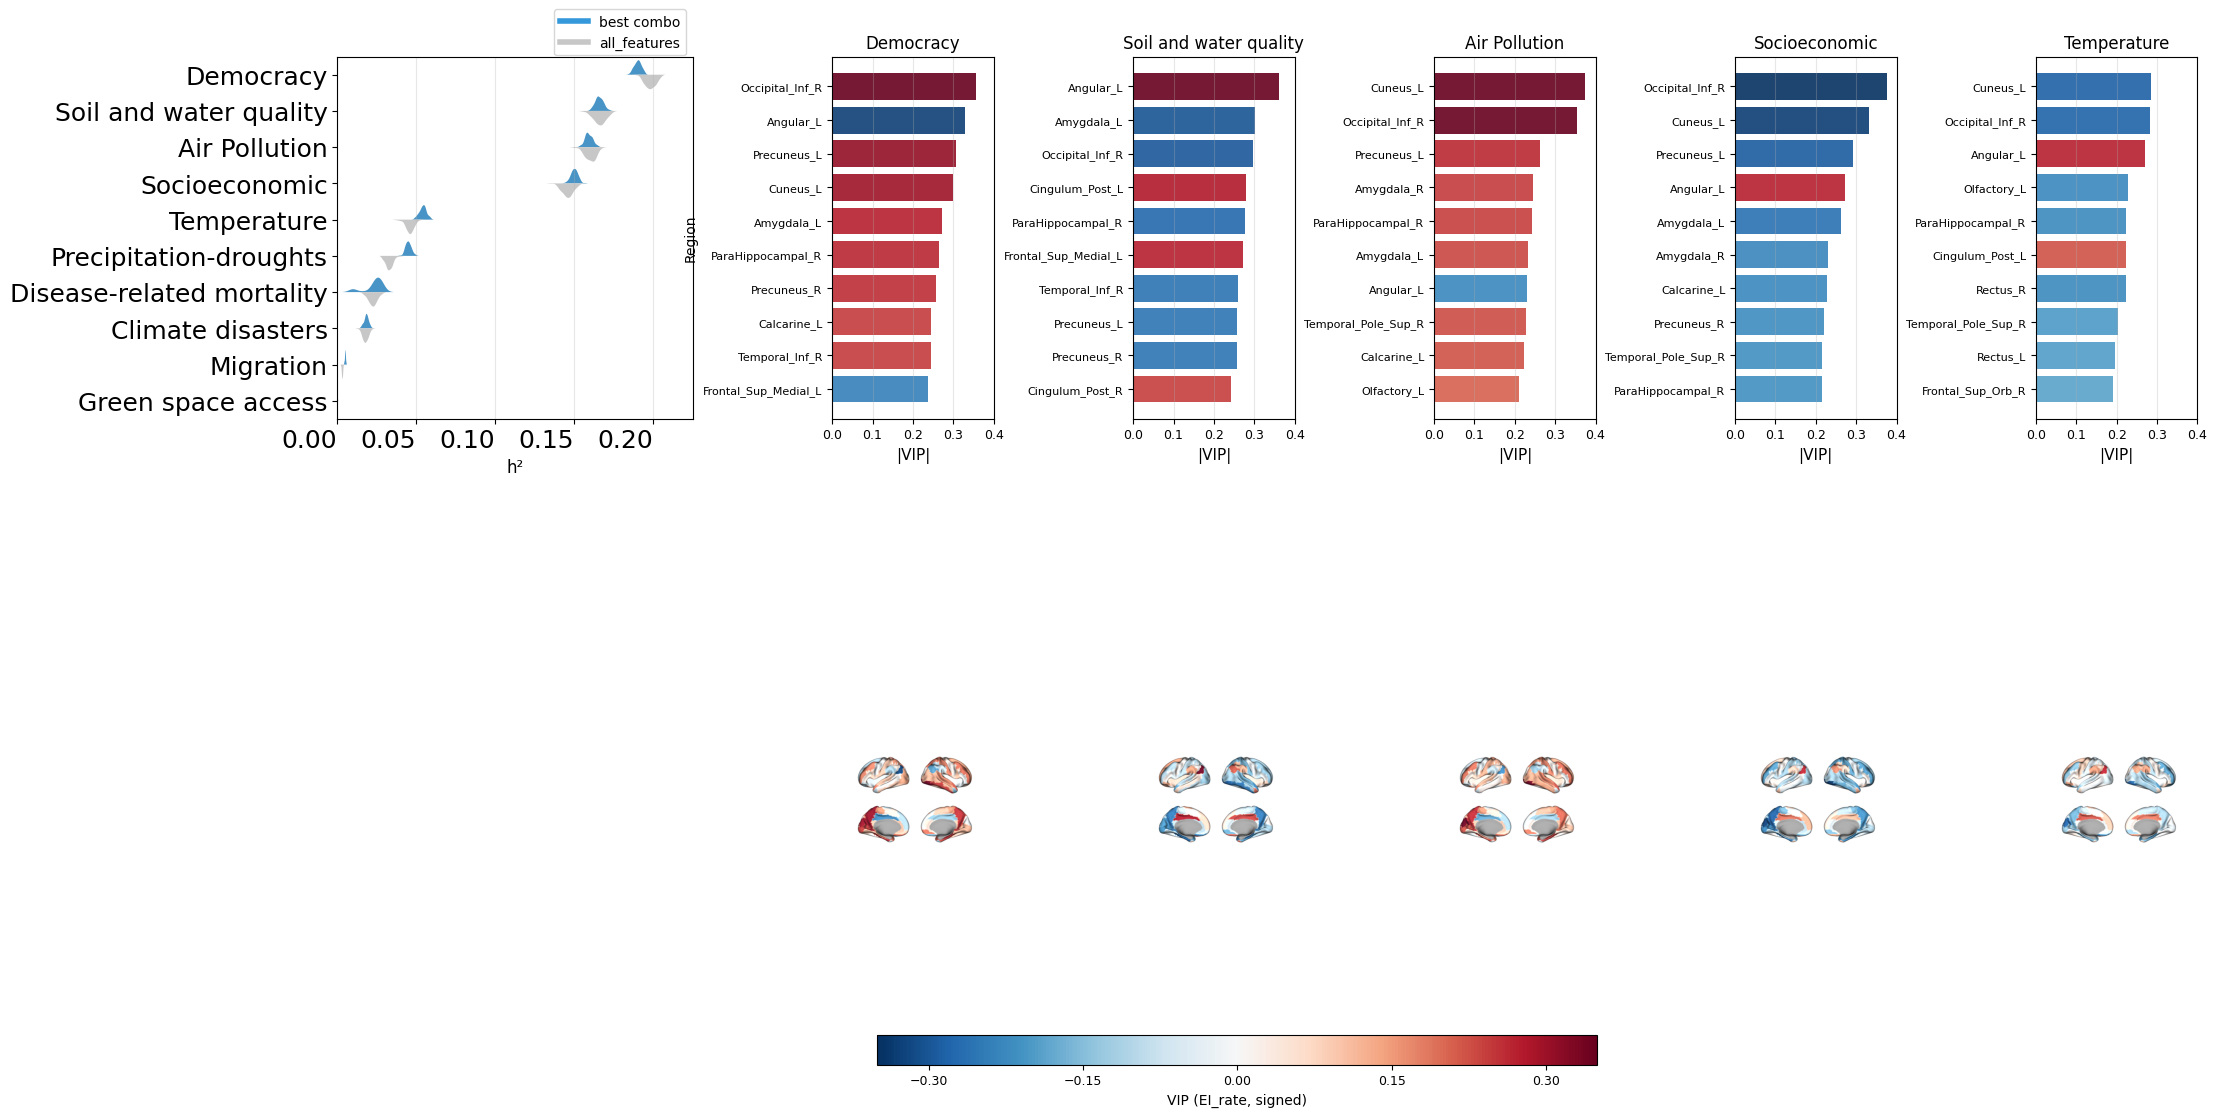

In [2]:

# Figure
fig = plt.figure(figsize=(24, 12))
gs = gridspec.GridSpec(2, 6, figure=fig, width_ratios=[2.2, 1, 1, 1, 1, 1], wspace=0.72, hspace=0.55)

# Column 1 top row only: vertical violins (labels can spill down into the blank space below)
ax_all = fig.add_subplot(gs[0, 0])
# sns.violinplot(
#     data=all_violin_df, y='exposome', x='h2', hue='condition', orient='h', split=True,
#     order=exposome_order, palette=VIOLIN_COLORS, linewidth=0, cut=0, legend=False
# )
sns.violinplot(data=all_violin_df, y='exposome', x='h2', hue='condition', split=True,
                palette=VIOLIN_COLORS, inner=None, 
                orient='h', density_norm='count')

for violin in ax_all.collections:
    violin.set_edgecolor(None)
    violin.set_linewidth(0)
# sns.stripplot(
#     data=all_violin_df, x='exposome', y='h2', hue='condition', orient='v', dodge=False,
#     order=exposome_order, palette=VIOLIN_COLORS, size=2.5, alpha=0.65, linewidth=0,
#     edgecolor='none', legend=False
# )
# ax_all.set_title('All exposomes: best vs all_features (h²)', fontsize=15)
ax_all.set_ylabel('')
ax_all.set_xlabel('h²', fontsize=12)
ax_all.tick_params(axis='y', labelsize=18)
ax_all.tick_params(axis='x', labelsize=18)
ax_all.set_xticks([0, 0.05, 0.1, 0.15, 0.2, 0.25])
max_h2 = all_violin_df['h2'].max()
ax_all.set_xlim(0, max_h2 + 0.02)
ax_all.xaxis.grid(True, alpha=0.3)
ax_all.yaxis.grid(False)
for label in ax_all.get_xticklabels():
    label.set_ha('right')

handles = [plt.Line2D([0], [0], color=VIOLIN_COLORS[0], lw=4, label='best combo'),
           plt.Line2D([0], [0], color=VIOLIN_COLORS[1], lw=4, label='all_features')]
ax_all.legend(handles=handles, loc='upper right', fontsize=10, bbox_to_anchor=(1, 1.15))

# Blank axis in bottom-left (keeps grid balance and lets labels spill)
fig.add_subplot(gs[1, 0]).axis('off')

# Columns 2–6: top exposomes
for idx, expo in enumerate(top_exposomes):
    col = idx + 1
    bundle = bundles[expo]

    # VIP bars (EI_rate only, top 8)
    ax_vip = fig.add_subplot(gs[0, col])
    vip_ei = top_vip_ei(bundle['vip_df'], top_n=10)
    colors = [cm.get_cmap(VIP_CMAP)(VIP_NORM(v)) for v in vip_ei['vip']]
    ax_vip.barh(vip_ei['label_short'], vip_ei['vip'].abs(), color=colors, alpha=0.9)
    ax_vip.invert_yaxis()
    ax_vip.set_xlabel('|VIP|', fontsize=11)
    if col == 1:
        ax_vip.set_ylabel('Region', fontsize=10)
    else:
        ax_vip.set_ylabel('')
    ax_vip.tick_params(axis='y', labelsize=8)
    ax_vip.tick_params(axis='x', labelsize=9)
    ax_vip.set_title(expo, fontsize=12)
    ax_vip.xaxis.grid(True, alpha=0.3)
    ax_vip.set_xlim(0, 0.4)

    # Brain map (EI_rate)
    ax_brain = fig.add_subplot(gs[1, col])
    vip_vec = (
        bundle['vip_df'][bundle['vip_df']['feature_group'] == 'EI_rate']
        .sort_values('feature', key=lambda x: x.str.extract(r'_(\d+)$').astype(int)[0])
        .vip.values
    )
    vip_vec_82 = remove_excluded_regions(vip_vec)
    brain_fig = plot_brain_map(vip_vec_82, vmin=VIP_NORM.vmin, vmax=VIP_NORM.vmax, cmap=VIP_CMAP)
    brain_fig.canvas.draw()
    buf = brain_fig.canvas.buffer_rgba()
    img = np.asarray(buf).reshape(brain_fig.canvas.get_width_height()[::-1] + (4,))
    img = img[..., :3]
    ax_brain.imshow(img)
    plt.close(brain_fig)
    ax_brain.axis('off')



# Shared VIP colorbar
cbar_ax = fig.add_axes([0.35, 0.04, 0.3, 0.025])
sm = cm.ScalarMappable(cmap=VIP_CMAP, norm=VIP_NORM)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('VIP (EI_rate, signed)', fontsize=10)
cbar.ax.tick_params(labelsize=9)
cbar.set_ticks([-0.3, -0.15, 0.0, 0.15, 0.3])

# plt.tight_layout(rect=[0, 0.07, 1, 0.98])
plt.tight_layout()

fig.savefig(FIG_DIR / 'expotype_pcev_odq_overview.png', dpi=300, bbox_inches='tight')
fig.savefig(FIG_DIR / 'expotype_pcev_odq_overview.pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIG_DIR / 'expotype_pcev_odq_overview.svg', dpi=300, bbox_inches='tight')
print(f'Single overview figure saved to {FIG_DIR}')
plt.show()


In [3]:
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

np.random.seed(42)

def paired_sign_flip_test(data_all, data_best, n_perm=10000, statistic="mean"):
    diff = np.array(data_all) - np.array(data_best)
    n = len(diff)
    if statistic == "mean":
        obs_stat = np.mean(diff)
    elif statistic == "median":
        obs_stat = np.median(diff)
    else:
        raise ValueError("statistic must be 'mean' or 'median'")
    signs = np.random.choice([-1, 1], size=(n_perm, n))
    if statistic == "mean":
        perm_stats = np.mean(signs * diff, axis=1)
    elif statistic == "median":
        perm_stats = np.median(signs * diff, axis=1)
    p_val = np.mean(np.abs(perm_stats) >= np.abs(obs_stat))
    return obs_stat, p_val

def bootstrap_ci(data, n_boot=10000, statistic="mean"):
    data = np.array(data)
    n = len(data)
    indices = np.random.randint(0, n, size=(n_boot, n))
    samples = data[indices]
    if statistic == "mean":
        boot_stats = np.mean(samples, axis=1)
    elif statistic == "median":
        boot_stats = np.median(samples, axis=1)
    else:
        raise ValueError("statistic must be 'mean' or 'median'")
    return np.percentile(boot_stats, 2.5), np.percentile(boot_stats, 97.5)

def get_simple_stats(data):
    return np.mean(data), np.std(data, ddof=1), len(data)

results_list = []

for expo in exposome_order:
    bund = bundles[expo]
    best_data = bund['h2_best']['h2_with'].values
    all_data  = bund['h2_all']['h2_with'].values

    best_mean, best_std, n = get_simple_stats(best_data)
    all_mean,  all_std,  _ = get_simple_stats(all_data)

    obs_stat, pval = paired_sign_flip_test(all_data, best_data, n_perm=10000, statistic="mean")
    diffs = all_data - best_data
    ci_lower, ci_upper = bootstrap_ci(diffs, n_boot=10000, statistic="mean")

    results_list.append({
        "Exposome":               expo,
        "Metric":                 "h²",
        "Best Subset":            bund['best_combo'],
        "Best Mean (SD)":         f"{best_mean:.6f} ({best_std:.6f})",
        "All Features Mean (SD)": f"{all_mean:.6f} ({all_std:.6f})",
        "N":                      n,
        "Test":                   "Paired sign-flip permutation (repeat-level)",
        "Δ (All - Best)":         f"{obs_stat:.6f}",
        "Δ 95% CI":               f"[{ci_lower:.6f}, {ci_upper:.6f}]",
        "P-value":                pval,
    })

stats_df = pd.DataFrame(results_list)
display(Markdown("### Statistical Comparison: Best Subset vs. All Features (Non-parametric)"))
display(stats_df)
print(stats_df.to_markdown(index=False))

stats_df.to_csv(TABLE_DIR / 'pcev_expotypes_best_vs_all.csv', index=False)
print(f"Saved to {TABLE_DIR / 'pcev_expotypes_best_vs_all.csv'}")


### Statistical Comparison: Best Subset vs. All Features (Non-parametric)

,Exposome,Metric,Best Subset,Best Mean (SD),All Features Mean (SD),N,Test,Δ (All - Best),Δ 95% CI,P-value
0,Democracy,h²,ent_I+rate_I,0.190420 (0.002232),0.198390 (0.003254),100,Paired sign-flip permutation (repeat-level),0.007970,"[0.007500, 0.008443]",0.0000
1,Soil and water quality,h²,EI_rate+rate_I,0.166002 (0.002520),0.166241 (0.003810),100,Paired sign-flip permutation (repeat-level),0.000239,"[-0.000359, 0.000830]",0.4400
2,Air Pollution,h²,ent_I+rate_I,0.159388 (0.002406),0.160330 (0.003406),100,Paired sign-flip permutation (repeat-level),0.000942,"[0.000409, 0.001461]",0.0001
3,Socioeconomic,h²,EI_ent+ent_E,0.150216 (0.002241),0.145898 (0.003434),100,Paired sign-flip permutation (repeat-level),-0.004317,"[-0.004834, -0.003819]",0.0000
4,Temperature,h²,EI_ent+ent_E,0.054221 (0.002245),0.045914 (0.002660),100,Paired sign-flip permutation (repeat-level),-0.008307,"[-0.008675, -0.007932]",0.0000
5,Precipitation-droughts,h²,rate_I,0.045028 (0.001838),0.032955 (0.002297),100,Paired sign-flip permutation (repeat-level),-0.012073,"[-0.012445, -0.011699]",0.0000
6,Disease-related mortality,h²,rate_E,0.023339 (0.005875),0.022458 (0.002733),100,Paired sign-flip permutation (repeat-level),-0.000881,"[-0.002145, 0.000419]",0.1837
7,Climate disasters,h²,rate_I,0.018367 (0.001433),0.017840 (0.001792),100,Paired sign-flip permutation (repeat-level),-0.000527,"[-0.000869, -0.000191]",0.0029
8,Migration,h²,EI_rate,0.005055 (0.000307),0.003193 (0.000369),100,Paired sign-flip permutation (repeat-level),-0.001862,"[-0.001925, -0.001800]",0.0000
9,Green space access,h²,ent_I,0.000097 (0.000114),0.000039 (0.000058),100,Paired sign-flip permutation (repeat-level),-0.000058,"[-0.000081, -0.000035]",0.0000


| Exposome                  | Metric   | Best Subset    | Best Mean (SD)      | All Features Mean (SD)   |   N | Test                                        |   Δ (All - Best) | Δ 95% CI               |   P-value |
|:--------------------------|:---------|:---------------|:--------------------|:-------------------------|----:|:--------------------------------------------|-----------------:|:-----------------------|----------:|
| Democracy                 | h²       | ent_I+rate_I   | 0.190420 (0.002232) | 0.198390 (0.003254)      | 100 | Paired sign-flip permutation (repeat-level) |         0.00797  | [0.007500, 0.008443]   |    0      |
| Soil and water quality    | h²       | EI_rate+rate_I | 0.166002 (0.002520) | 0.166241 (0.003810)      | 100 | Paired sign-flip permutation (repeat-level) |         0.000239 | [-0.000359, 0.000830]  |    0.44   |
| Air Pollution             | h²       | ent_I+rate_I   | 0.159388 (0.002406) | 0.160330 (0.003406)      | 100 | Paired sign-flip permutatio

In [4]:
# Collect top 10 EI_rate VIPs for all exposomes
all_top_10_vip = []
for expo in bundles.keys():
    vip_df_expo = bundles[expo]['vip_df']
    vip_ei = vip_df_expo[vip_df_expo['feature_group'] == 'EI_rate'].copy()
    vip_ei['abs_vip'] = vip_ei['vip'].abs()
    vip_top10 = vip_ei.sort_values('abs_vip', ascending=False).head(10)
    vip_top10['region'] = vip_top10['feature'].apply(feature_to_region)
    vip_top10 = vip_top10[['exposome', 'region', 'vip']]
    all_top_10_vip.append(vip_top10)

all_top_10_vip_df = pd.concat(all_top_10_vip, ignore_index=True)
csv_path = TABLE_DIR / 'expotype_top10_vip.csv'
all_top_10_vip_df.to_csv(csv_path, index=False)
print(f"Exported top 10 VIPs per exposome to {csv_path}")

Exported top 10 VIPs per exposome to /home/rherzog/Documents/Brainlat/repo_test/analysis/tables/expotype_top10_vip.csv


## Likelihood ratio test with single exposore of exposome-derived PCEV scores

In [5]:
# Load LME LRT results produced by analysis_05_lme_expotypes.py
TABLE_DIR_ANALYSIS = REPO_ROOT / 'analysis/tables_for_paper'
lme_results_path = TABLE_DIR_ANALYSIS / 'expotype_lme_lrt.csv'

if not lme_results_path.exists():
    raise FileNotFoundError(
        f"LME results not found at {lme_results_path}.\n"
        "Run analysis/analysis_05_lme_expotypes.py first."
    )

final_df = pd.read_csv(lme_results_path)
print(f"Loaded LME results: {final_df.shape[0]} rows from {lme_results_path}")

cols_show = ['Exposome', 'Variable', 'Beta', 'Beta_CI_Low', 'Beta_CI_High', 'P_LRT', 'FDR_q_lrt', 'Delta_AIC']
from IPython.display import display
display(final_df.sort_values(['Exposome', 'FDR_q_lrt'])[cols_show])

sig = final_df[final_df['FDR_q_lrt'] < 0.001].groupby('Exposome').size()
print("\nSignificant (FDR q < 0.001) per domain:")
print(sig if not sig.empty else "None")

Loaded LME results: 68 rows from /home/rherzog/Documents/Brainlat/repo_test/analysis/tables_for_paper/expotype_lme_lrt.csv


,Exposome,Variable,Beta,Beta_CI_Low,Beta_CI_High,P_LRT,FDR_q_lrt,Delta_AIC
2,Air Pollution,Sulfur dioxide (SO₂),0.068226,-0.030135,0.166587,0.149659,0.612508,-0.075722
6,Air Pollution,Non-methane volatile organic compounds (NMVOC),-0.087474,-0.228009,0.053062,0.175002,0.612508,0.160438
0,Air Pollution,PM2.5,0.059254,-0.087110,0.205619,0.320761,0.748441,1.014157
5,Air Pollution,Ammoniac Nitrogen (NH3),-0.090790,-0.248100,0.066519,0.434673,0.760678,1.389695
3,Air Pollution,Carbon monoxide (CO),0.006671,-0.150192,0.163534,0.543591,0.761028,1.631076
...,...,...,...,...,...,...,...,...
16,Temperature,Mean temperature pop-weighted,-0.055856,-0.127516,0.015804,0.232713,1.000000,0.575798
17,Temperature,Mean temperature anomalies,0.026298,-0.007508,0.060104,0.566600,1.000000,1.671596
18,Temperature,Mean temperature anomalies pop-weighted,0.017084,-0.013909,0.048077,1.000000,1.000000,2.830312
19,Temperature,Deviation of temperature anomalies,0.065962,-0.039748,0.171673,1.000000,1.000000,2.565419



Significant (FDR q < 0.001) per domain:
Exposome
Disease-related mortality    2
Soil and water quality       1
dtype: int64


Saved LME barplot to /home/rherzog/Documents/Brainlat/repo_test/analysis/figures/expotype_lrt_barplot.png


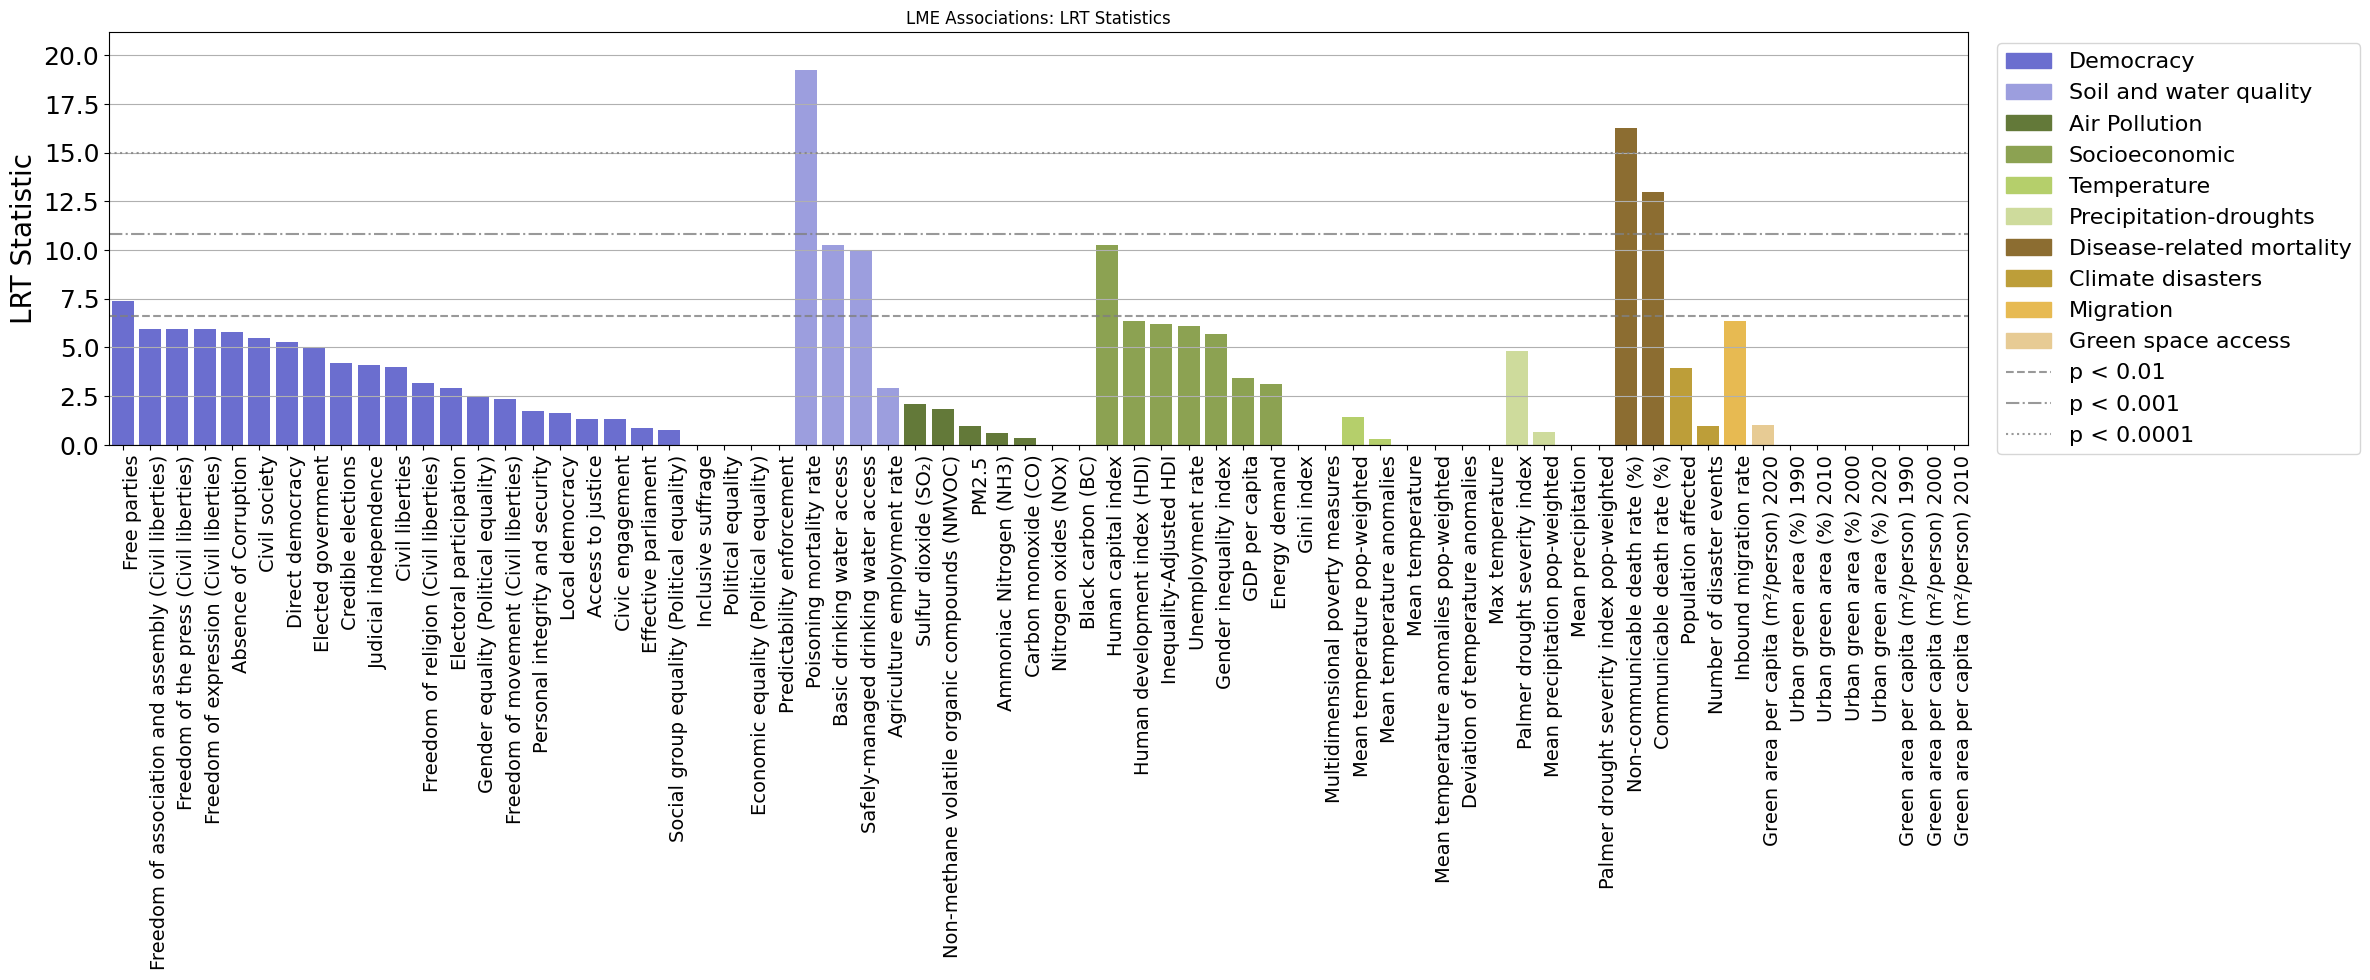

In [6]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

tab20b = sns.color_palette('tab20b', 20)
remove_idx = [0, 1, 12, 13, 14, 15]
custom_palette = [c for i, c in enumerate(tab20b) if i not in remove_idx][:10]

def plot_lme_barplot(lme_df, fname, title='LME Associations: LRT Statistics', custom_ylim=None):
    if lme_df.empty:
        print('No LME results to plot.')
        return

    plot_df = lme_df.copy().rename(columns={
        'Exposome': 'exposome', 'Variable': 'variable',
        'LRT_Stat': 'value', 'FDR_q_lrt': 'q'
    }).dropna(subset=['value'])
    plot_df['exposome'] = plot_df['exposome'].astype(str)
    plot_df['variable'] = plot_df['variable'].astype(str)

    # Sort domains by mean h2 using bundles already loaded
    exposome_domains = sorted(
        plot_df['exposome'].unique(),
        key=lambda d: bundles[d]['h2_mean'] if d in bundles else 0,
        reverse=True
    )

    exposome2color = {e: custom_palette[i % len(custom_palette)] for i, e in enumerate(exposome_domains)}

    variable_order = []
    for expo in exposome_domains:
        sub = plot_df[plot_df['exposome'] == expo]
        variable_order.extend(
            [(expo, v) for v in sub.sort_values('value', ascending=False)['variable'].tolist()]
        )

    plot_df['var_label'] = plot_df['exposome'] + ': ' + plot_df['variable']
    order_labels = [f'{e}: {v}' for e, v in variable_order]
    plot_df['var_label'] = pd.Categorical(plot_df['var_label'], categories=order_labels, ordered=True)
    plot_df = plot_df.sort_values('var_label')

    max_val = np.nanmax(plot_df['value'])
    ylim = custom_ylim if custom_ylim is not None else (0, max(max_val * 1.1, 16))

    fig, ax = plt.subplots(figsize=(max(12, 0.35 * len(plot_df)), 6))
    bar_colors = [exposome2color[expo] for expo, _ in variable_order]
    ax.bar(np.arange(len(plot_df)), plot_df['value'],
           color=bar_colors, edgecolor=None, alpha=1, linewidth=0)

    l1 = ax.axhline(6.6,  color='gray', linestyle='--', linewidth=1.5, alpha=0.8, label='p < 0.01')
    l2 = ax.axhline(10.8, color='gray', linestyle='-.', linewidth=1.5, alpha=0.8, label='p < 0.001')
    l3 = ax.axhline(15.0, color='gray', linestyle=':',  linewidth=1.5, alpha=0.8, label='p < 0.0001')

    ax.set_xticks(np.arange(len(plot_df)))
    ax.set_xticklabels(plot_df['variable'], rotation=90, ha='left', fontsize=14)
    ax.set_ylim(ylim)
    ax.set_xlim(-0.5, len(plot_df) - 0.5)
    for lbl in ax.get_yticklabels():
        lbl.set_fontsize(18)
    ax.yaxis.grid(True)
    ax.xaxis.grid(False)

    domain_handles = [mpatches.Patch(color=exposome2color[e], label=e) for e in exposome_domains]
    ax.legend(handles=domain_handles + [l1, l2, l3],
              bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=16)
    ax.axhline(0, color='k', lw=0.8, alpha=0.7)
    ax.set_ylabel('LRT Statistic', fontsize=20)
    ax.set_title(title)
    fig.tight_layout()
    fig.subplots_adjust(bottom=0.25)
    fig.savefig(fname.with_suffix('.pdf'), dpi=300, bbox_inches='tight')
    fig.savefig(fname, dpi=300, bbox_inches='tight')
    print('Saved LME barplot to', fname)
    plt.show()

plot_lme_barplot(
    final_df,
    FIG_DIR / 'expotype_lrt_barplot.png',
    title='LME Associations: LRT Statistics'
)